In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from metashapes.shape import Rectangle, Stripe, Triangle, Egg, Star, TShape, Cross
from metashapes.lattice.basis import Lattice
from metashapes.lattice.unit_cell import UnitCell
from metashapes.lattice.grid import cartesian_grid

dtype = torch.float32
device = 'cuda:0'

In [2]:
# Create lattice for visualisation
Lx = 1.0
Ly = 1.0
nx = 256
ny = 256

lattice = Lattice.rectangular(Lx, Ly)
lattice = lattice.to(dtype=dtype, device=device)

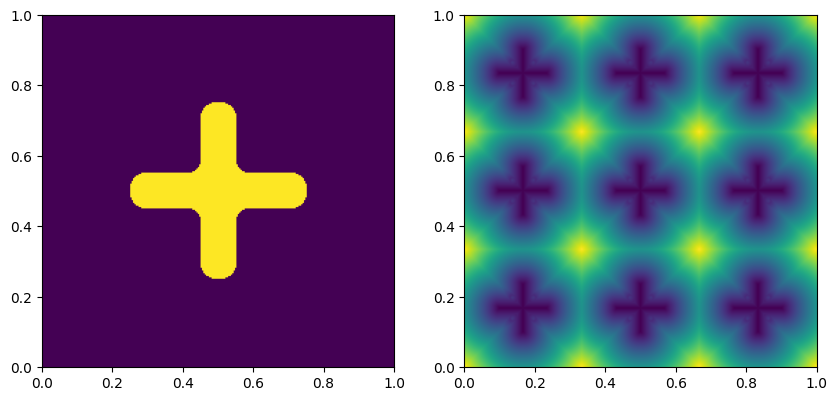

In [30]:
# Cross
center        = torch.nn.Parameter(torch.tensor([0.5, 0.5]))
length          = torch.nn.Parameter(torch.tensor(0.5))
width          = torch.nn.Parameter(torch.tensor(0.1))
angle         = torch.nn.Parameter(torch.tensor(0.0))
outer_corner_radius = torch.tensor(0.04)
inner_corner_radius = torch.tensor(0.04)

cross = Cross(center, length, width, angle, outer_corner_radius, inner_corner_radius)
cross = cross.to(dtype=dtype, device=device)
cross_cell = UnitCell(lattice=lattice, scene=cross)

image = cross_cell.mask(nx, ny, repeat=(1, 1), cartesian=True, soft=False, softness=0.04)

sdf = cross_cell.rasterize(nx, ny, cartesian=True, repeat=(3, 3))

fc = torch.tensor([[0,0],[1,0],[0,1],[1,1]], dtype=lattice.dtype, device=lattice.device)
cx, cy = lattice.to_cartesian(fc[:,0], fc[:,1])
extent = [cx.min().item(), cx.max().item(), cy.min().item(), cy.max().item()]

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(image.cpu().detach(), aspect='equal', extent=extent, origin='lower')

plt.subplot(122)
plt.imshow(sdf.cpu().detach(), aspect='equal', extent=extent, origin='lower')

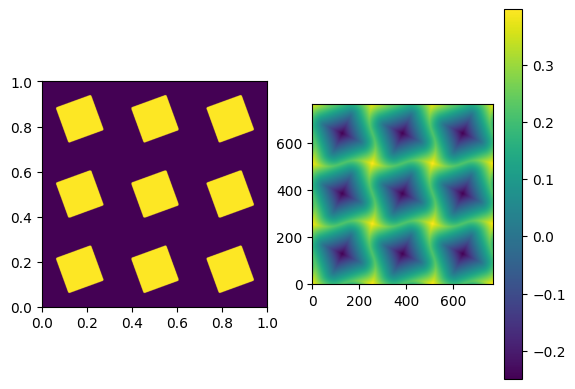

In [31]:
# Rectangle
center        = torch.nn.Parameter(torch.tensor([0.5, 0.5]))
size          = torch.nn.Parameter(torch.tensor([0.5, 0.5]))
angle         = torch.nn.Parameter(torch.tensor(20.0))
corner_radius = torch.tensor(0.02)

rect = Rectangle(center=center, size=size, angle=angle, corner_radius=corner_radius)
rect = rect.to(dtype=dtype, device=device)
rect_cell = UnitCell(lattice=lattice, scene=rect)

image = rect_cell.mask(nx, ny, repeat=(3, 3), cartesian=True, soft=False, softness=0.04)

sdf = rect_cell.rasterize(nx, ny, cartesian=True, repeat=(3, 3))

fc = torch.tensor([[0,0],[1,0],[0,1],[1,1]], dtype=lattice.dtype, device=lattice.device)
cx, cy = lattice.to_cartesian(fc[:,0], fc[:,1])
extent = [cx.min().item(), cx.max().item(), cy.min().item(), cy.max().item()]

plt.figure()
plt.subplot(121)
plt.imshow(image.cpu().detach(), aspect='equal', extent=extent, origin='lower')

plt.subplot(122)
plt.imshow(sdf.cpu().detach(), origin='lower')
plt.colorbar()

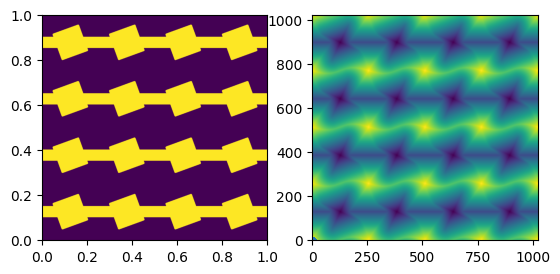

In [32]:
# Stripe
offset        = torch.nn.Parameter(torch.tensor(0.5))
width          = torch.nn.Parameter(torch.tensor(0.2))
axis         = 'x'

stripe = Stripe(offset, width, axis)
stripe = stripe.to(dtype=dtype, device=device)
stripe_cell = UnitCell(lattice=lattice, scene=(stripe.union(rect.rotate(-0, origin=(0.5, 0.5)))))

image = stripe_cell.mask(nx, ny, repeat=(4, 4), cartesian=True)

sdf = stripe_cell.rasterize(nx, ny, cartesian=True, repeat=(4, 4))

fc = torch.tensor([[0,0],[1,0],[0,1],[1,1]], dtype=lattice.dtype, device=lattice.device)
cx, cy = lattice.to_cartesian(fc[:,0], fc[:,1])
extent = [cx.min().item(), cx.max().item(), cy.min().item(), cy.max().item()]

plt.figure()
plt.subplot(121)
plt.imshow(image.cpu().detach(), aspect='equal', extent=extent, origin='lower')

plt.subplot(122)
plt.imshow(sdf.cpu().detach(), origin='lower')
plt.scatter(stripe_cell.boundary_points()[:,0], stripe_cell.boundary_points()[:,1], s = 10)

In [5]:
stripe_cell.boundary_points().shape

(2316, 2)

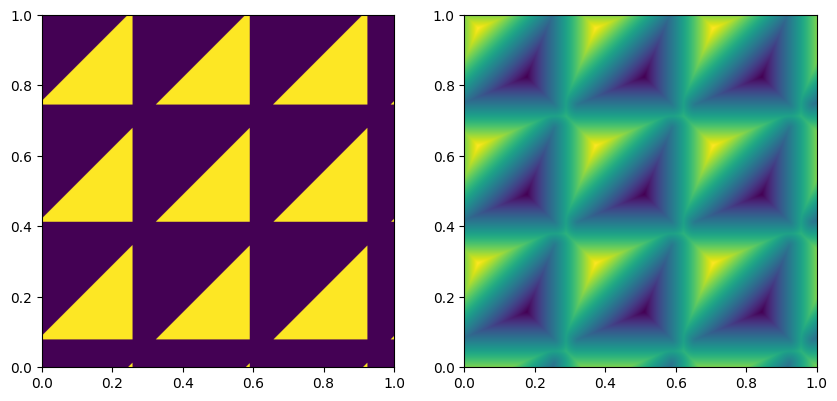

In [33]:
# Triangle
center        = torch.nn.Parameter(torch.tensor([0.5, 0.5]))
base          = torch.nn.Parameter(torch.tensor(0.8))
alpha          = torch.nn.Parameter(torch.tensor(45.0))
beta          = torch.nn.Parameter(torch.tensor(90.0))
angle         = torch.nn.Parameter(torch.tensor(0.0))
corner_radius = torch.tensor(0.0)

tri = Triangle(center, base, alpha, beta, angle, corner_radius)
tri = tri.to(dtype=dtype, device=device)
tri_cell = UnitCell(lattice=lattice, scene=tri)

image = tri_cell.mask(nx, ny, repeat=(3, 3), cartesian=True, soft=False, softness=0.04)

sdf = tri_cell.rasterize(nx, ny, cartesian=True, repeat=(3, 3))

fc = torch.tensor([[0,0],[1,0],[0,1],[1,1]], dtype=lattice.dtype, device=lattice.device)
cx, cy = lattice.to_cartesian(fc[:,0], fc[:,1])
extent = [cx.min().item(), cx.max().item(), cy.min().item(), cy.max().item()]

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(image.cpu().detach(), aspect='equal', extent=extent, origin='lower')

plt.subplot(122)
plt.imshow(sdf.cpu().detach(), aspect='equal', extent=extent, origin='lower')

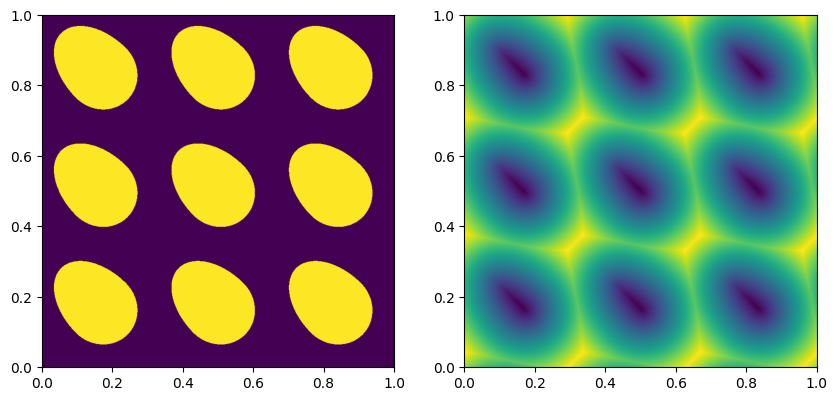

In [34]:
# Egg
center        = torch.nn.Parameter(torch.tensor([0.5, 0.5]))
width          = torch.nn.Parameter(torch.tensor(0.6))
height          = torch.nn.Parameter(torch.tensor(0.8))
skew          = torch.nn.Parameter(torch.tensor(0.2))
angle         = torch.nn.Parameter(torch.tensor(45.0))

egg = Egg(center, width, height, skew, angle)
egg = egg.to(dtype=dtype, device=device)
egg_cell = UnitCell(lattice=lattice, scene=egg)

image = egg_cell.mask(nx, ny, repeat=(3, 3), cartesian=True, soft=False, softness=0.04)

sdf = egg_cell.rasterize(nx, ny, cartesian=True, repeat=(3, 3))

fc = torch.tensor([[0,0],[1,0],[0,1],[1,1]], dtype=lattice.dtype, device=lattice.device)
cx, cy = lattice.to_cartesian(fc[:,0], fc[:,1])
extent = [cx.min().item(), cx.max().item(), cy.min().item(), cy.max().item()]

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(image.cpu().detach(), aspect='equal', extent=extent, origin='lower')

plt.subplot(122)
plt.imshow(sdf.cpu().detach(), aspect='equal', extent=extent, origin='lower')

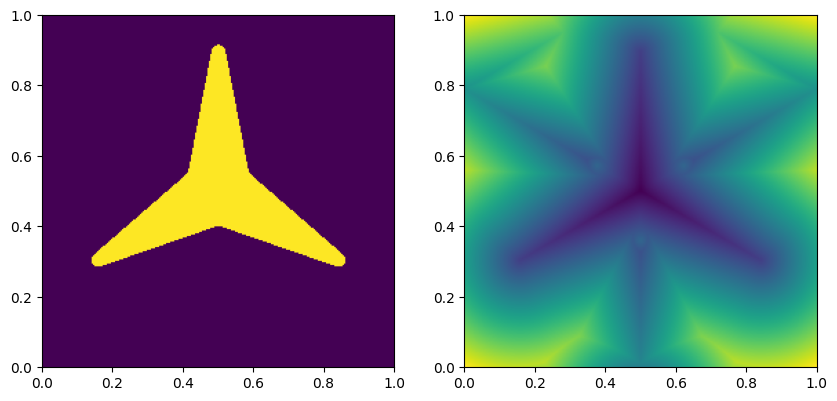

In [12]:
# Star
center        = torch.nn.Parameter(torch.tensor([0.5, 0.5]))
n = 3
outer_radius          = torch.nn.Parameter(torch.tensor(0.5))
inner_radius          = torch.nn.Parameter(torch.tensor(0.1))
angle         = torch.nn.Parameter(torch.tensor(0.0))
outer_corner_radius = torch.nn.Parameter(torch.tensor(0.02))
inner_corner_radius = torch.nn.Parameter(torch.tensor(0.04))

star = Star(center, n, outer_radius, inner_radius, angle, outer_corner_radius, inner_corner_radius)
star = star.to(dtype=dtype, device=device)
lattice = lattice.to(dtype=dtype, device=device)
star_cell = UnitCell(lattice=lattice, scene=star)

image = star_cell.mask(nx, ny, repeat=(1, 1), cartesian=True, soft=False, softness=0.04)

sdf = star_cell.rasterize(nx, ny, cartesian=True, repeat=(1, 1))

fc = torch.tensor([[0,0],[1,0],[0,1],[1,1]], dtype=lattice.dtype, device=lattice.device)
cx, cy = lattice.to_cartesian(fc[:,0], fc[:,1])
extent = [cx.min().item(), cx.max().item(), cy.min().item(), cy.max().item()]

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(image.cpu().detach(), aspect='equal', extent=extent, origin='lower')

plt.subplot(122)
plt.imshow(sdf.cpu().detach(), aspect='equal', extent=extent, origin='lower')

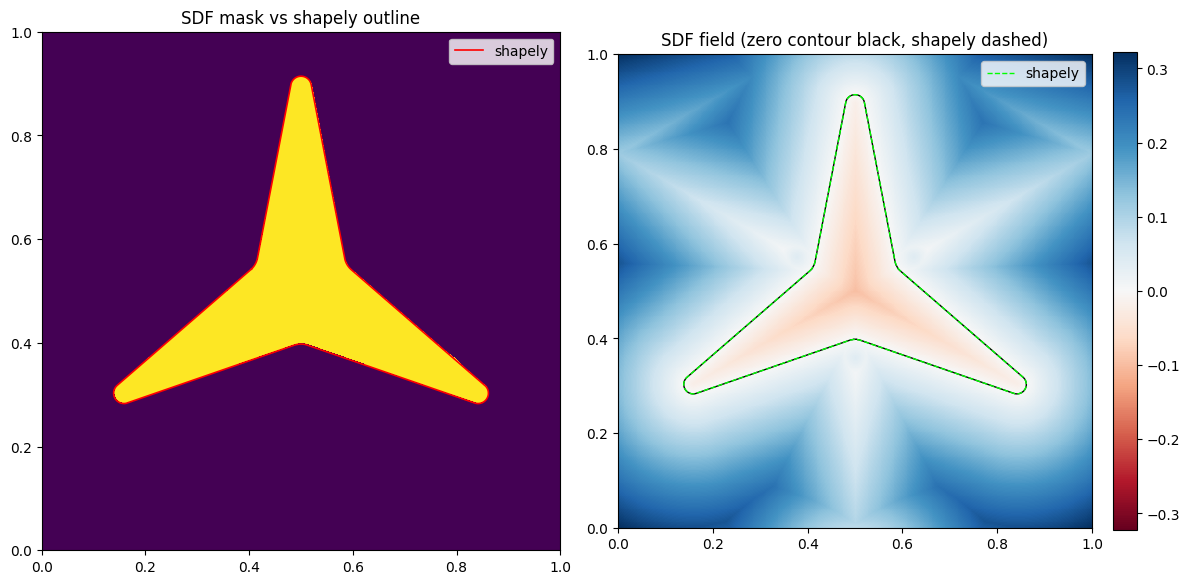

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon


def plot_sdf_vs_shapely(star_cell, nx=512, ny=512, extent=(0.0, 1.0, 0.0, 1.0)):
    """
    Overlay the SDF mask with the shapely polygon outline.

    Left:   SDF mask (filled) with shapely outline on top.
    Right:  SDF field with zero-contour and shapely outline overlaid.
    """
    # SDF-based mask and field
    mask = star_cell.mask(nx, ny, repeat=(1, 1), cartesian=True,
                          soft=False, softness=0.04).cpu()
    mask = np.asarray(mask)

    # If a signed-distance field is available, grab it for the right panel.
    # Adjust this if your API exposes the SDF differently.
    x0, x1, y0, y1 = extent
    xs = np.linspace(x0, x1, nx)
    ys = np.linspace(y0, y1, ny)
    XX, YY = np.meshgrid(xs, ys, indexing="xy")

    import torch
    with torch.no_grad():
        xt = torch.as_tensor(XX, dtype=torch.float64)
        yt = torch.as_tensor(YY, dtype=torch.float64)
        sdf_field = star_cell.sdf(xt, yt).cpu().numpy()

    # Shapely outline
    geom = star_cell.to_shapely()

    def iter_rings(g):
        if isinstance(g, Polygon):
            yield np.asarray(g.exterior.coords)
            for hole in g.interiors:
                yield np.asarray(hole.coords)
        elif isinstance(g, MultiPolygon):
            for part in g.geoms:
                yield from iter_rings(part)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # ---- Left: mask + shapely outline ----
    ax = axes[0]
    ax.imshow(mask, origin="lower", extent=extent, cmap="viridis",
              interpolation="nearest")
    for ring in iter_rings(geom):
        ax.plot(ring[:, 0], ring[:, 1], color="red", linewidth=1.2,
                label="shapely")
    ax.set_title("SDF mask vs shapely outline")
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_aspect("equal")
    # dedupe legend
    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        seen.setdefault(l, h)
    ax.legend(seen.values(), seen.keys(), loc="upper right")

    # ---- Right: SDF field + zero contour + shapely outline ----
    ax = axes[1]
    vmax = np.nanmax(np.abs(sdf_field))
    im = ax.imshow(sdf_field, origin="lower", extent=extent, cmap="RdBu",
                   vmin=-vmax, vmax=vmax, interpolation="nearest")
    ax.contour(XX, YY, sdf_field, levels=[0.0], colors="black", linewidths=1.0)
    for ring in iter_rings(geom):
        ax.plot(ring[:, 0], ring[:, 1], color="lime", linewidth=1.0,
                linestyle="--", label="shapely")
    ax.set_title("SDF field (zero contour black, shapely dashed)")
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_aspect("equal")
    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        seen.setdefault(l, h)
    ax.legend(seen.values(), seen.keys(), loc="upper right")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# usage
plot_sdf_vs_shapely(star_cell.cpu())